# Proyecto Final: Transformación y Modelado de Indicadores Socioeconómicos en Latinoamérica

**Curso:** CC3074 - Minería de Datos  
**Framework:** CRISP-DM - Fase 1: Comprensión del Negocio y los Datos  
**Fuente de datos:** CEPALSTAT - Observatorio de Desarrollo Digital (ODD)  
**Indicador:** Personas usuarias de Internet por grupo etario, países seleccionados de América Latina y el Caribe  

**Integrantes:** 
 
- Cristian Túnchez (231359)  
- Dulce Ambrosio (231143)  
- Daniel Chet (231177)  
- Javier Linares (231135)  

## Semana 1 - Análisis Exploratorio de Datos: Uso de Internet por Grupo Etario en América Latina (2000-2022)

---
### Contexto del "Negocio"

El acceso a Internet es un indicador clave de desarrollo digital y social. Este conjunto de datos, publicado por la Comision Economica para America Latina y el Caribe (CEPAL), mide el porcentaje de personas que utilizan Internet en 14 países latinoaméricanos, desglosado por grupo etario, a lo largo de más de dos decadas (2000-2022).

Comprender los patrones de adopción digital, las brechas entre grupos de edad y las diferencias entre países es fundamental para:

- Políticas públicas de inclusión digital
- Estrategias de alfabetización tecnológica
- Análisis de la brecha digital intergeneracional

**Objetivo del EDA:** Explorar la estructura, calidad y patrones principales del dataset para identificar problemas de datos y formular hipótesis para fases posteriores de Minería de Datos.

**Configuración del entorno e importación de librerías**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator
from scipy import stats as sp_stats
import warnings

warnings.filterwarnings('ignore')

# Configuracion visual
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
sns.set_style('whitegrid')
sns.set_palette('Set2')

# Paleta personalizada para grupos etarios (de joven a mayor)
PALETA_EDAD = {
    'edad de medicion a 17 años': '#2196F3',
    '18 a 25 años de edad': '#4CAF50',
    '26 a 50 años de edad': '#FF9800',
    '51 a 65 años': '#F44336',
    '66 años en adelante': '#9C27B0',
    'Total': '#607D8B'
}

ORDEN_EDAD = [
    'edad de medicion a 17 años',
    '18 a 25 años de edad',
    '26 a 50 años de edad',
    '51 a 65 años',
    '66 años en adelante',
    'Total'
]

# Etiquetas cortas para gráficos
ETIQUETAS_CORTAS = {
    'edad de medicion a 17 años': '<=17 años',
    '18 a 25 años de edad': '18-25',
    '26 a 50 años de edad': '26-50',
    '51 a 65 años': '51-65',
    '66 años en adelante': '66+',
    'Total': 'Total'
}

print('Entorno configurado correctamente.')
print(f'pandas: {pd.__version__}')
print(f'numpy: {np.__version__}')

Entorno configurado correctamente.
pandas: 3.0.0
numpy: 2.4.2


**Carga de datos desde el archivo Excel**

In [2]:
df = pd.read_excel('data.xlsx', sheet_name='datos')
metadatos = pd.read_excel('data.xlsx', sheet_name='metadatos')
fuentes = pd.read_excel('data.xlsx', sheet_name='fuentes')
notas = pd.read_excel('data.xlsx', sheet_name='notas')
creditos = pd.read_excel('data.xlsx', sheet_name='creditos')

print(f'Dataset principal cargado: {df.shape[0]} filas x {df.shape[1]} columnas')
print(f'\nHojas auxiliares cargadas:')
print(f'  metadatos: {metadatos.shape}')
print(f'  fuentes:   {fuentes.shape}')
print(f'  notas:     {notas.shape}')
print(f'  créditos:  {creditos.shape}')

Dataset principal cargado: 870 filas x 8 columnas

Hojas auxiliares cargadas:
  metadatos: (12, 2)
  fuentes:   (1, 6)
  notas:     (0, 1)
  créditos:  (4, 2)


---
### 1. Descripción General del Conjunto de Datos

En esta sección se describe la estructura del dataset: el significado y tipo de cada variable, la cantidad de observaciones y variables, y se examinan los metadatos proporcionados por CEPAL.

**Vista general del dataset**

In [3]:
print('=' * 70)
print('ESTRUCTURA DEL DATASET')
print('=' * 70)
print(f'\nDimensiones: {df.shape[0]} observaciones x {df.shape[1]} variables')
print(f'\nColumnas y tipos de datos:')
print('-' * 50)
df.info()

ESTRUCTURA DEL DATASET

Dimensiones: 870 observaciones x 8 variables

Columnas y tipos de datos:
--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 870 entries, 0 to 869
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   indicator                    870 non-null    str    
 1   País__ESTANDAR               870 non-null    str    
 2   Grupos etarios Uso Internet  870 non-null    str    
 3   Años__ESTANDAR               870 non-null    int64  
 4   value                        870 non-null    float64
 5   unit                         870 non-null    str    
 6   notes_ids                    0 non-null      float64
 7   source_id                    870 non-null    int64  
dtypes: float64(2), int64(2), str(4)
memory usage: 54.5 KB


**Primeras y últimas observaciones**

In [4]:
print('Primeras 5 filas:')
display(df.head())

print('\nÚltimas 5 filas:')
display(df.tail())

Primeras 5 filas:


,indicator,País__ESTANDAR,Grupos etarios Uso Internet,Años__ESTANDAR,value,unit,notes_ids,source_id
0,Personas usuarias de Internet por grupo etario...,Argentina,edad de medicion a 17 años,2016,75.9,Porcentaje sobre el total de personas en cada ...,NaN,9353
1,Personas usuarias de Internet por grupo etario...,Argentina,edad de medicion a 17 años,2017,75.9,Porcentaje sobre el total de personas en cada ...,NaN,9353
2,Personas usuarias de Internet por grupo etario...,Argentina,edad de medicion a 17 años,2018,78.5,Porcentaje sobre el total de personas en cada ...,NaN,9353
3,Personas usuarias de Internet por grupo etario...,Argentina,edad de medicion a 17 años,2019,78.9,Porcentaje sobre el total de personas en cada ...,NaN,9353
4,Personas usuarias de Internet por grupo etario...,Argentina,edad de medicion a 17 años,2020,87.5,Porcentaje sobre el total de personas en cada ...,NaN,9353



Últimas 5 filas:


,indicator,País__ESTANDAR,Grupos etarios Uso Internet,Años__ESTANDAR,value,unit,notes_ids,source_id
865,Personas usuarias de Internet por grupo etario...,Uruguay,Total,2015,64.6,Porcentaje sobre el total de personas en cada ...,NaN,9353
866,Personas usuarias de Internet por grupo etario...,Uruguay,Total,2016,71.9,Porcentaje sobre el total de personas en cada ...,NaN,9353
867,Personas usuarias de Internet por grupo etario...,Uruguay,Total,2017,76.7,Porcentaje sobre el total de personas en cada ...,NaN,9353
868,Personas usuarias de Internet por grupo etario...,Uruguay,Total,2018,80.7,Porcentaje sobre el total de personas en cada ...,NaN,9353
869,Personas usuarias de Internet por grupo etario...,Uruguay,Total,2019,83.4,Porcentaje sobre el total de personas en cada ...,NaN,9353


#### 1.1 Significado y Tipo de Cada Variable

| # | Variable | Tipo en pandas | Tipo conceptual | Descripción |
|---|----------|---------------|-----------------|-------------|
| 1 | `indicator` | object (string) | Categórica nominal (constante) | Nombre descriptivo del indicador. **Valor unico** para todas las filas. |
| 2 | `País__ESTANDAR` | object (string) | Categórica nominal | Nombre del país (14 paises latinoamericanos). |
| 3 | `Grupos etarios Uso Internet` | object (string) | Categórica ordinal | Grupo de edad: menores de 17, 18-25, 26-50, 51-65, 66+, y Total. |
| 4 | `Años__ESTANDAR` | int64 | Temporal (discreta) | Año de medicion (2000, 2003-2022). |
| 5 | `value` | float64 | Numérica continua | **Variable objetivo:** Porcentaje de personas usuarias de Internet en cada grupo etario. Rango [0, 100]. |
| 6 | `unit` | object (string) | Categórica nominal (constante) | Unidad de medida. **Valor único** para todas las filas. |
| 7 | `notes_ids` | float64 | Identificador | Identificadores de notas. **100% nulo** en este dataset. |
| 8 | `source_id` | int64 | Identificador (constante) | ID de la fuente de datos. **Valor unico** (9353) para todas las filas. |

**Observaciones clave sobre las variables:**
- Solo **1 variable es realmente numérica** (`value`) - el porcentaje de uso de Internet.
- **4 variables son constantes o nulas** (`indicator`, `unit`, `source_id`, `notes_ids`) y no aportan información diferenciadora.
- Las **3 variables categóricas informativas** (`País__ESTANDAR`, `Grupos etarios Uso Internet`, `Años__ESTANDAR`) definen las dimensiones del panel de datos.
- El dataset tiene estructura de **datos de panel**: País x Grupo Etario x Año.

**Valores únicos por columna**

In [5]:
print('=' * 70)
print('VALORES ÚNICOS POR VARIABLE')
print('=' * 70)

for col in df.columns:
    n_unique = df[col].nunique()
    n_null = df[col].isnull().sum()
    pct_null = (n_null / len(df)) * 100
    print(f'\n{"─" * 50}')
    print(f'{col}')
    print(f'   Valores únicos: {n_unique} | Nulos: {n_null} ({pct_null:.1f}%)')
    if n_unique <= 25:
        print(f'   Valores: {sorted(df[col].dropna().unique().tolist(), key=str)}')
    else:
        print(f'   Ejemplo: {df[col].dropna().iloc[0]}')

VALORES ÚNICOS POR VARIABLE

──────────────────────────────────────────────────
indicator
   Valores únicos: 1 | Nulos: 0 (0.0%)
   Valores: ['Personas usuarias de Internet por grupo etario, países seleccionados América Latina y el Caribe, 2000 a 2022']

──────────────────────────────────────────────────
País__ESTANDAR
   Valores únicos: 14 | Nulos: 0 (0.0%)
   Valores: ['Argentina', 'Bolivia (Estado Plurinacional de)', 'Brasil', 'Chile', 'Colombia', 'Costa Rica', 'Ecuador', 'El Salvador', 'Honduras', 'México', 'Panamá', 'Paraguay', 'Perú', 'Uruguay']

──────────────────────────────────────────────────
Grupos etarios Uso Internet
   Valores únicos: 6 | Nulos: 0 (0.0%)
   Valores: ['18 a 25 años de edad', '26 a 50 años de edad', '51 a 65 años', '66 años en adelante', 'Total', 'edad de medicion a 17 años']

──────────────────────────────────────────────────
Años__ESTANDAR
   Valores únicos: 21 | Nulos: 0 (0.0%)
   Valores: [2000, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012

**Metadatos del indicador (de la hoja 'metadatos')**

In [6]:
print('=' * 70)
print('METADATOS DEL INDICADOR')
print('=' * 70)
display(metadatos)

print('\n' + '=' * 70)
print('FUENTE DE DATOS')
print('=' * 70)
display(fuentes)

print('\n' + '=' * 70)
print('CRÉDITOS')
print('=' * 70)
display(creditos)

METADATOS DEL INDICADOR


,metadata,value
0,indicator_id,4987
1,indicator_name,Personas usuarias de Internet por grupo etario...
2,theme,Tecnologías de Información y Comunicación
3,area,Uso individual de TIC
4,note,El uso de Internet se miden en Argentina a par...
5,unit,Porcentaje sobre el total de personas en cada ...
6,data_features,NaN
7,definition,Personas usuarias de Internet por grupo etario...
8,calculation_methodology,100*(Cantidad de usuarios de Internet en cada ...
9,comments,NaN



FUENTE DE DATOS


,id,organization_name,description,organization_url,organization_acronym,publication_url
0,9353,Comisión Económica para América Latina y el Ca...,Observatorio de Desarrollo Digital (ODD) sobre...,http://www.eclac.org/,CEPAL,NaN



CRÉDITOS


,id,description
0,0,2026-04-25
1,1,CEPALSTAT
2,2,Comisión Económica para América Latina y el Ca...
3,3,Naciones Unidas


#### 1.2 Problemas de Calidad de Datos Identificados

1. **Variables redundantes/constantes (4 de 8):**
   - `indicator`: Valor idéntico en todas las filas. No aporta variabilidad.
   - `unit`: Valor idéntico en todas las filas ("Porcentaje sobre el total de personas en cada grupo etario").
   - `source_id`: Valor idéntico en todas las filas (9353).
   - `notes_ids`: **100% nulo** - columna completamente vacía.
   
2. **Datos de panel incompletos:**
   - El producto cruzado completo (14 países x 21 años x 6 grupos etarios) sería 1,764 registros.
   - Solo hay 870 registros: **completitud del 49.3%**.
   - Cada país tiene datos para diferentes rangos de años.
   
3. **Heterogeneidad en la edad de medición:**
   - Según los metadatos, la edad mínima de medición varía por país:
     - 4 años: Argentina
     - 5 años: Bolivia, Chile, Colombia, Costa Rica, Ecuador, Honduras
     - 6 años: Uruguay, Perú
     - 10 años: Brasil, El Salvador, Panamá, Paraguay
   - Esto afecta la comparabilidad del grupo "edad de medición a 17 años".

4. **Cobertura temporal desigual:**
   - Algunos países tienen datos para 17 años; otros solo para 7.
   - Hay brechas temporales significativas dentro de los países.

5. **Tipo de dato de `Años__ESTANDAR`:** Cargado como `int64`, pero podría convertirse a `datetime` para análisis de series temporales.

**Mapa de calor de cobertura temporal por país**

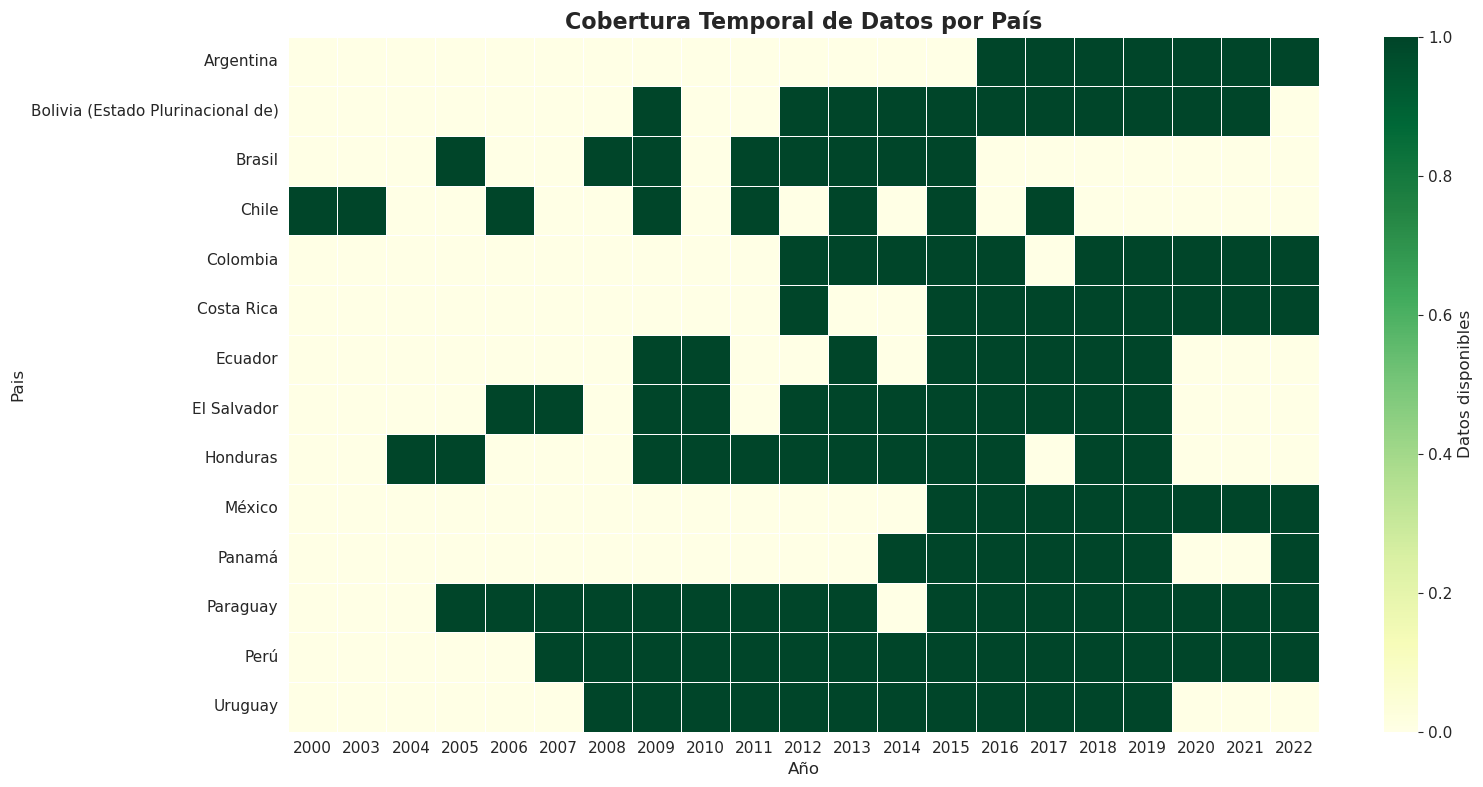


Completitud del dataset: 870 / 1764 posibles = 49.3%


In [7]:
fig, ax = plt.subplots(figsize=(16, 8))

# Crear matriz de presencia de datos
coverage = df.groupby(['País__ESTANDAR', 'Años__ESTANDAR']).size().unstack(fill_value=0)
coverage = (coverage > 0).astype(int)

sns.heatmap(coverage, cmap='YlGn', cbar_kws={'label': 'Datos disponibles'},
            linewidths=0.5, linecolor='white', ax=ax,
            xticklabels=True, yticklabels=True)
ax.set_title('Cobertura Temporal de Datos por País', fontsize=16, fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('Pais')
plt.tight_layout()
plt.show()

total_posible = 14 * 21 * 6
print(f'\nCompletitud del dataset: {len(df)} / {total_posible} posibles = {len(df)/total_posible*100:.1f}%')

**Cantidad de observaciones por país**

,observaciones,año_min,año_max,años_distintos
País__ESTANDAR,,,,
Paraguay,102,2005,2022,17
Perú,96,2007,2022,16
Honduras,72,2004,2019,12
El Salvador,72,2006,2019,12
Uruguay,72,2008,2019,12
Bolivia (Estado Plurinacional de),66,2009,2021,11
Colombia,60,2012,2022,10
Costa Rica,54,2012,2022,9
Chile,48,2000,2017,8


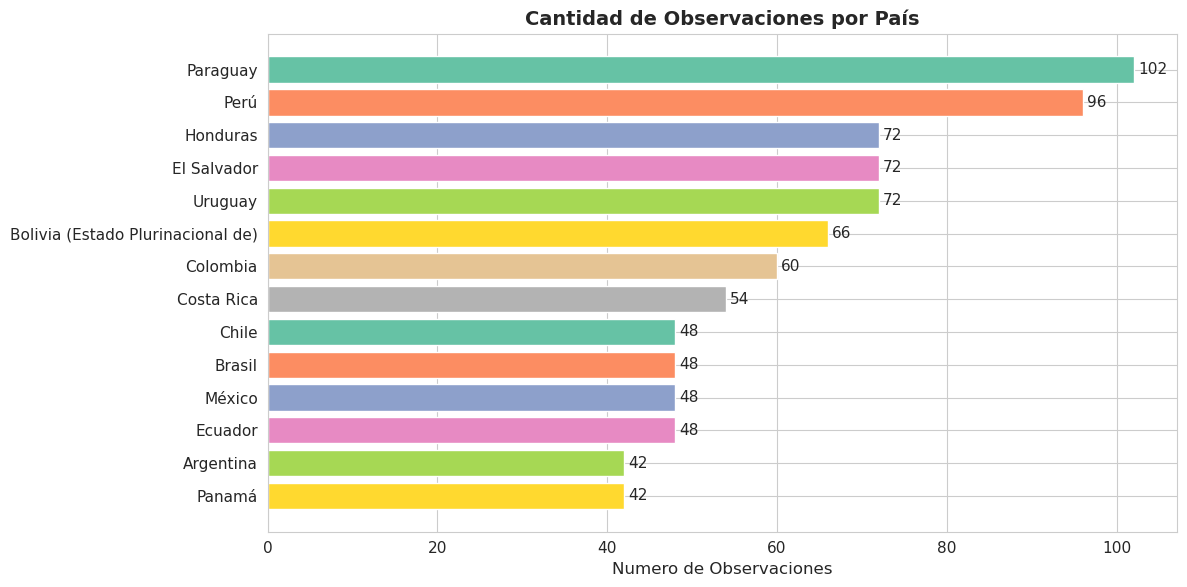

In [8]:
obs_pais = df.groupby('País__ESTANDAR').agg(
    observaciones=('value', 'count'),
    año_min=('Años__ESTANDAR', 'min'),
    año_max=('Años__ESTANDAR', 'max'),
    años_distintos=('Años__ESTANDAR', 'nunique')
).sort_values('observaciones', ascending=False)

display(obs_pais)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(obs_pais.index, obs_pais['observaciones'], color=sns.color_palette('Set2', len(obs_pais)))
ax.set_xlabel('Numero de Observaciones')
ax.set_title('Cantidad de Observaciones por País', fontsize=14, fontweight='bold')
ax.bar_label(bars, padding=3)
ax.invert_yaxis()
plt.tight_layout()
plt.show()